In [74]:
# 1. Настройка автоперезагрузки модулей (удобно при разработке)
%load_ext autoreload
%autoreload 2

# 2. Импорт центрального конфига путей
import config as cnfg

# 3. Проверка и создание папок (если их нет)
# При первом запуске он создаст папки data/raw, data/processed и т.д.
cnfg.init_structure()

# 4. Библиотечные импорты
import matplotlib.pyplot as plt
import pandas as pd

# 5. Импорт ваших расчетных модулей
from scripts import import_data as idt
from scripts import data_manager as dm
from scripts import plot_manager as pm
# from scripts import pressure_predictor as ppm
from scripts import pressure_predictor_lite as prm
from scripts import optimizator as opt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
--- Проверка структуры проекта ---
[OK] data\raw
[OK] data\processed
[OK] data\config
[OK] gui
----------------------------------



In [75]:
# # Ячейка 3: Запуск обработки
# df_logs, df_registry = idt.run_extraction(
#     raw_dir=cnfg.RAW_DATA_DIR,
#     logs_file=cnfg.LOGS_FILE,
#     reg_file=cnfg.REGISTRY_FILE,
#     settings=cnfg.EXTRACTION_SETTINGS,
#     col_config=cnfg.COLUMNS_CONFIG
# )

In [76]:
df_logs = dm.load_database(cnfg.LOGS_FILE)
df_registry = dm.load_database(cnfg.REGISTRY_FILE)
df_reference_setpoint = dm.load_database(cnfg.REFERENCE_SETPOINT_FILE)

Загрузка: cycles_logs.csv
Загрузка: cycles_registry.csv
Загрузка: ТК.20-500.895.1-7.4. ред.0 (настроечные параметры дезоксидации).csv


In [77]:
df_reference_setpoint = df_reference_setpoint.astype({'Dia_Shell': int, 'L_Shell': int})
dm.show_columns_list(df_reference_setpoint)


--- Список полей ---
"Dia_Shell",
"L_Shell",
"Q_deoxidation",
"Time_cycle",
"First_cycle",
"p_tank_preset_1",
"p_tank_preset_2",
"p_tank_preset_3",
"p_tank_preset_4",
"p_tank_preset_5",
"p_tank_preset_6",
"p_tank_preset_7",
"p_tank_preset_8",
"p_tank_preset_9",
"p_tank_preset_10",
"p_pipe_preset_1",
"p_pipe_preset_2",
"p_pipe_preset_3",
"p_pipe_preset_4",
"p_pipe_preset_5",
"p_pipe_preset_6",
"p_pipe_preset_7",
"p_pipe_preset_8",
"p_pipe_preset_9",
"p_pipe_preset_10",


In [78]:
df_registry = idt.classify_registry_generic(df_registry, cnfg.CLASSIFICATION_TASKS)

[Classify] Создана колонка 'Dia_Shell' на основе 'LD11C1\Process Data.BarDiameter (Диаметр заготовки)'
[Classify] Создана колонка 'L_Shell' на основе 'CtpOut002_Shell_length (Длина гильзы)'


In [79]:
dm.save_database(df_logs, cnfg.LOGS_FILE)
dm.save_database(df_registry, cnfg.REGISTRY_FILE)
dm.save_database(df_reference_setpoint, cnfg.REFERENCE_SETPOINT_FILE)

In [80]:
group_cols = ["Dia_Shell", "L_Shell"]
detailed_cols = [
    "IBA_DB\PT1014 Актуальное давление в трубе (бар)",
    "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
    "IBA_DB\PT1010 Актуальное давление в спирали (бар)",
    "LD31W.Weigh P1 - вес в баке",  
    "LD31W.Vessel.PT1009 - давление баке",
    "LD31W.VALVE 1007 - клапан бака, бар",
    "LD31W.VALVE 1008 - клапан трубы, бар",
    "X1213_CLS - клапан порошка закр", 
]
df_avg_logs, df_avg_registry = dm.get_averaged_profiles(
    df_logs, 
    df_registry, 
    cnfg.CLASSIFICATION_TASKS, 
    detailed_cols)


In [81]:
df_avg_logs = df_avg_logs.astype({'Dia_Shell': int, 'L_Shell': int})
df_avg_registry = df_avg_registry.astype({'Dia_Shell': int, 'L_Shell': int})

In [82]:
df_avg_logs = dm.apply_target_logic(
    df_avg_logs, 
    df_avg_registry, 
    df_reference_setpoint, 
    cnfg.CONFIG_ADD_SETTINGS
    )
# dm.save_database(df_avg_logs, cnfg.LOGS_AVG_FILE)
# dm.save_database(df_avg_registry, cnfg.REGISTRY_AVG_FILE)

In [83]:
cnfg_params, flat_params = dm.load_config(cnfg.DEFAULT_MODEL_PARAMS_FILE)

In [84]:
df_avg_logs, df_avg_registry = prm.apply_analytic_model(
    df_avg_logs, 
    df_avg_registry,
    cnfg.CONFIG_ADD_SETTINGS['columns'], 
    flat_params
    )

In [85]:
cycle_ids = [
    "AVG_D_273_L_7000",
    "AVG_D_273_L_9000",
    "AVG_D_273_L_10000",
    "AVG_D_182_L_8000",
    "AVG_D_182_L_5000",
    "AVG_D_273_L_8000"    
]

# df_avg_logs, df_avg_registry = dm.remove_cycles_from_data(df_avg_logs, df_avg_registry, cycle_ids, col_cycle='cycle_id')

In [86]:
dm.save_database(df_avg_logs, cnfg.LOGS_AVG_FILE)
dm.save_database(df_avg_registry, cnfg.REGISTRY_AVG_FILE)

*Алгоритм оптимизации 

In [95]:
params_to_tune = ["dead_time", "k_gain", "b_gain", "damping"]

best_params, raw_result = opt.run_universal_optimizer(
    df_avg_logs, 
    df_avg_registry, 
    cnfg_params,
    cnfg.CONFIG_ADD_SETTINGS['columns'], 
    params_to_tune
)

# best_params теперь содержит что-то вроде:
# {'dead_time': 0.12, 'k_gain': 0.035, 'b_gain': 0.015, 'damping': 0.42}

--- ОПТИМИЗАЦИЯ ПАРАМЕТРОВ: ['dead_time', 'k_gain', 'b_gain', 'damping'] ---
 Шаг: 1.2%, MAE: 0.01346
 Шаг: 1.3%, MAE: 0.01346
 Шаг: 1.4%, MAE: 0.01346
 Шаг: 1.5%, MAE: 0.00807
 Шаг: 2.0%, MAE: 0.00807
 Шаг: 2.1%, MAE: 0.00807
 Шаг: 2.3%, MAE: 0.00807
 Шаг: 2.8%, MAE: 0.00807
 Шаг: 2.6%, MAE: 0.00807
 Шаг: 4.0%, MAE: 0.00807
 Шаг: 4.7%, MAE: 0.00807
 Шаг: 5.3%, MAE: 0.00807
 Шаг: 5.9%, MAE: 0.00807
 Шаг: 8.0%, MAE: 0.00807
 Шаг: 9.2%, MAE: 0.00807
 Шаг: 11.6%, MAE: 0.00807
 Шаг: 12.0%, MAE: 0.00807
 Шаг: 16.5%, MAE: 0.00807
 Шаг: 17.6%, MAE: 0.00807
 Шаг: 41.7%, MAE: 0.00803
 Шаг: 62.6%, MAE: 0.00803
 Шаг: 97.8%, MAE: 0.00803
 Шаг: 108.8%, MAE: 0.00803

📋 ДЕТАЛЬНЫЙ ОТЧЕТ ОБ ОПТИМИЗАЦИИ
Статус оптимизации:       ✅ УСПЕШНО
Причина остановки:        Optimization terminated successfully.
Общее время:              45.28 сек
-------------------------------------------------------
Лучшее MAE (ошибка):      0.008032 бар
Кол-во поколений:         23
Всего расчетов модели:    1535 раз
----------

In [96]:
dm.save_config(best_params, cnfg.CONFIG_DIR / "Optimal_model_params_6_15.json")


Конфигурация сохранена: Optimal_model_params_6_15.json


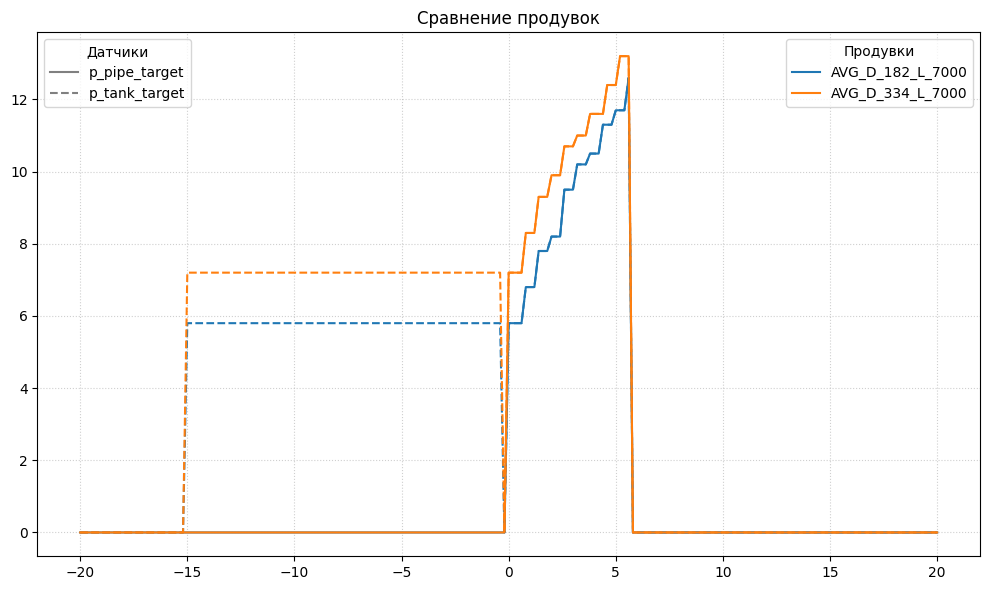

In [16]:
%matplotlib inline
# %matplotlib widget
identifiers = [
    # "AVG_D_182_L_6000",
    "AVG_D_182_L_7000",
    # "AVG_D_182_L_9000",
    # "AVG_D_182_L_10000",
    # "AVG_D_273_L_8000", 
    # "AVG_D_273_L_10000", 
    # "AVG_D_273_L_11300",
    "AVG_D_334_L_7000",
    # "AVG_D_334_L_8000"
    ]
sensors = [
    # "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
    # "LD31W.VALVE 1007 - клапан бака, бар",
    # "IBA_DB\PT1014 Актуальное давление в трубе (бар)",

    # "LD31W.VALVE 1007 - клапан бака, бар_median",   
    # "LD31W.VALVE 1008 - клапан трубы, бар"
    # 'p_tank_theory',
    "p_pipe_target",
    # 'p_residual_error',
    'p_tank_target',
    # "p_cycle_mae"
    # "LD31W.Weigh P1 - вес в баке"
 ]
pm.plot_cycles(df_avg_logs, df_avg_registry, identifiers, sensors)
# plt.xlim(-18, 20)
# plt.xlim(-18, 20)
# plt.ylim(-0.05, 0.6)
# plt.plot(result_df['t_relative'], result_df['p_tank_theory'], label='Модельное давление в баке', color='orange')

In [17]:
dm.show_columns_list(df_avg_logs)
dm.show_columns_list(df_avg_registry)


--- Список полей ---
"Dia_Shell",
"L_Shell",
"t_relative",
"Curve_cycle_1",
"Curve_cycle_2",
"Curve_cycle_3",
"Curve_cycle_4",
"Curve_cycle_5",
"Curve_cycle_6",
"Curve_cycle_7",
"Curve_cycle_8",
"Curve_cycle_9",
"DB_Internal\Cmd_PUY1019 - давление в спирали",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_median",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_std",
"IBA_DB\PT1010 Актуальное давление в спирали (бар)",
"IBA_DB\PT1010 Актуальное давление в спирали (бар)_median",
"IBA_DB\PT1010 Актуальное давление в спирали (бар)_std",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)_median",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)_std",
"LD31W.Spray.PT1014 - давление трубе",
"LD31W.VALVE 1007 - клапан бака, бар",
"LD31W.VALVE 1007 - клапан бака, бар_median",
"LD31W.VALVE 1007 - клапан бака, бар_std",
"LD31W.VALVE 1008 - клапан трубы, бар",
"LD31W.VALVE 1008 - клапан т

In [18]:
dm.get_summary(df_avg_registry, only_labeled=False)

,cycle_id,duration,Dia_Shell,L_Shell,n_samples
0,AVG_D_182_L_10000,7.426748,182,10000,329
1,AVG_D_182_L_5000,6.142857,182,5000,77
2,AVG_D_182_L_6000,6.570960,182,6000,427
3,AVG_D_182_L_7000,6.818750,182,7000,352
4,AVG_D_182_L_8000,6.950473,182,8000,634
5,AVG_D_182_L_9000,7.235503,182,9000,169
6,AVG_D_273_L_10000,7.730753,273,10000,465
7,AVG_D_273_L_11300,7.705882,273,11300,34
8,AVG_D_273_L_6000,6.725581,273,6000,43
9,AVG_D_273_L_7000,6.966296,273,7000,629


(-0.05, 0.6)

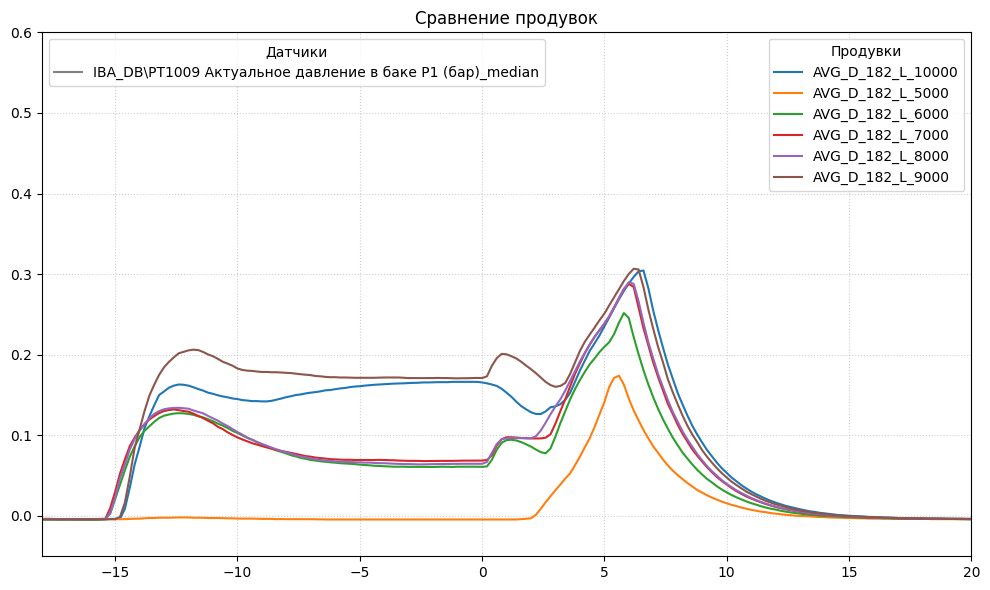

In [19]:
%matplotlib inline
# %matplotlib widget
identifiers = [
    "AVG_D_182_L_5000",
    "AVG_D_182_L_6000",
    "AVG_D_182_L_7000",
    "AVG_D_182_L_8000",
    "AVG_D_182_L_9000",
    "AVG_D_182_L_10000", 
    ]
# identifiers = [
#     "AVG_D_273_L_6000",
#     "AVG_D_273_L_7000",
#     "AVG_D_273_L_8000",
#     "AVG_D_273_L_9000",
#     "AVG_D_273_L_10000",
#     "AVG_D_273_L_11300", 
#     ]
# identifiers = [
#     "AVG_D_334_L_7000",
#     "AVG_D_334_L_8000",
#     "AVG_D_334_L_11300", 
#     ]
sensors = [
    # "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
    "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_median",
    # "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_std",
    # "LD31W.VALVE 1007 - клапан бака, бар",
    # "IBA_DB\PT1014 Актуальное давление в трубе (бар)",
    # "IBA_DB\PT1014 Актуальное давление в трубе (бар)_median",
    # "IBA_DB\PT1014 Актуальное давление в трубе (бар)_std",
    # 'p_tank_theory',
    # 'p_residual_error',
    # "p_cycle_mae",
    # "LD31W.Weigh P1 - вес в баке",
    # "LD31W.Weigh P1 - вес в баке_median",
    # "LD31W.Weigh P1 - вес в баке_std"

 ]
pm.plot_cycles(df_avg_logs, df_avg_registry, identifiers, sensors)
# plt.title("Сравнение циклов по выбранным датчикам")
plt.xlim(-18, 20)
plt.ylim(-0.05, 0.6)
# plt.plot(result_df['t_relative'], result_df['p_tank_theory'], label='Модельное давление в баке', color='orange')

In [20]:
sensor = "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)"
# sensor = "IBA_DB\PT1014 Актуальное давление в трубе (бар)"

# 1. Получаем список всех уникальных cycle_id из таблицы средних значений
avg_ids = df_avg_logs['cycle_id'].unique()


# 2. Запускаем цикл
for avg_id in avg_ids:
    try:
        # Можно добавить принт, чтобы следить за процессом
        print(f" -> Отрисовка группы: {avg_id}")
        
        pm.plot_group_diagnostics(
            df_logs, 
            df_registry, 
            df_avg_logs, 
            avg_id, 
            sensor, 
            cnfg.CLASSIFICATION_TASKS,
            cnfg.GRAF_RESALTS_DIR,
            ymin = -0.01,
            ymax=0.6
        )
        
        # Чтобы графики не копились в оперативной памяти (важно!)
        plt.close('all') 
        
    except Exception as e:
        print(f" [!] Ошибка в группе {avg_id}: {e}")

print("Обработка завершена.")

 -> Отрисовка группы: AVG_D_182_L_10000
 -> Отрисовка группы: AVG_D_182_L_5000
 -> Отрисовка группы: AVG_D_182_L_6000
 -> Отрисовка группы: AVG_D_182_L_7000
 -> Отрисовка группы: AVG_D_182_L_8000
 -> Отрисовка группы: AVG_D_182_L_9000
 -> Отрисовка группы: AVG_D_273_L_10000
 -> Отрисовка группы: AVG_D_273_L_11300
 -> Отрисовка группы: AVG_D_273_L_6000
 -> Отрисовка группы: AVG_D_273_L_7000
 -> Отрисовка группы: AVG_D_273_L_8000
 -> Отрисовка группы: AVG_D_273_L_9000
 -> Отрисовка группы: AVG_D_334_L_11300
 -> Отрисовка группы: AVG_D_334_L_7000
 -> Отрисовка группы: AVG_D_334_L_8000
Обработка завершена.


In [21]:
# avg_id = "AVG_D_182_L_6000"
# avg_id = "AVG_D_334_L_11300"
avg_id = "AVG_D_273_L_7000"

(4.0, 10.0)

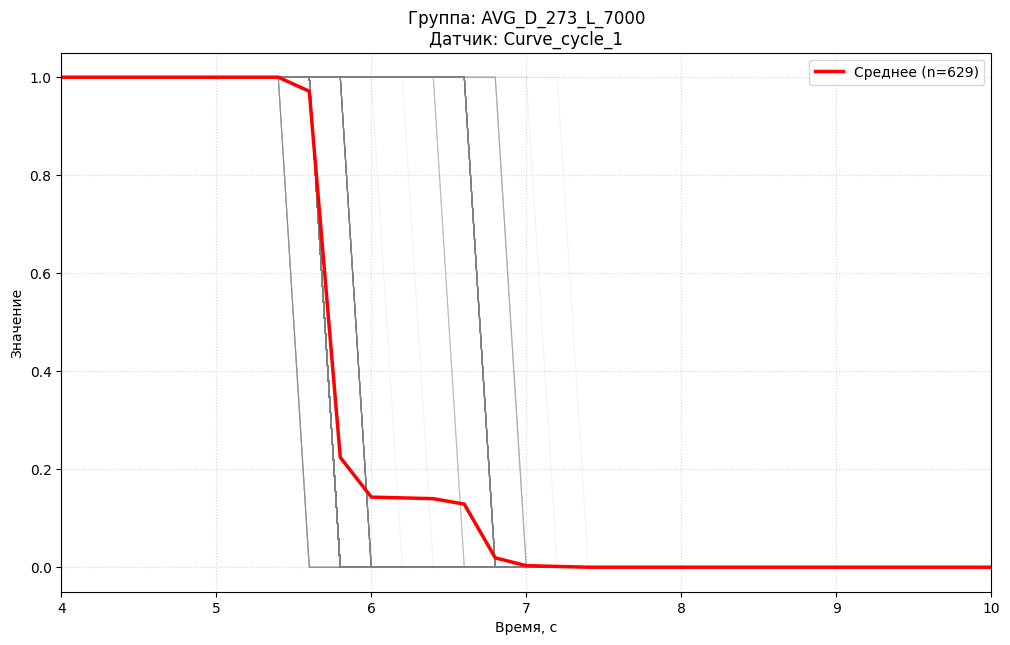

In [22]:
sensor = "Curve_cycle_1"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg.GRAF_RESALTS_DIR)
plt.xlim(4, 10)

(-20.0, 10.0)

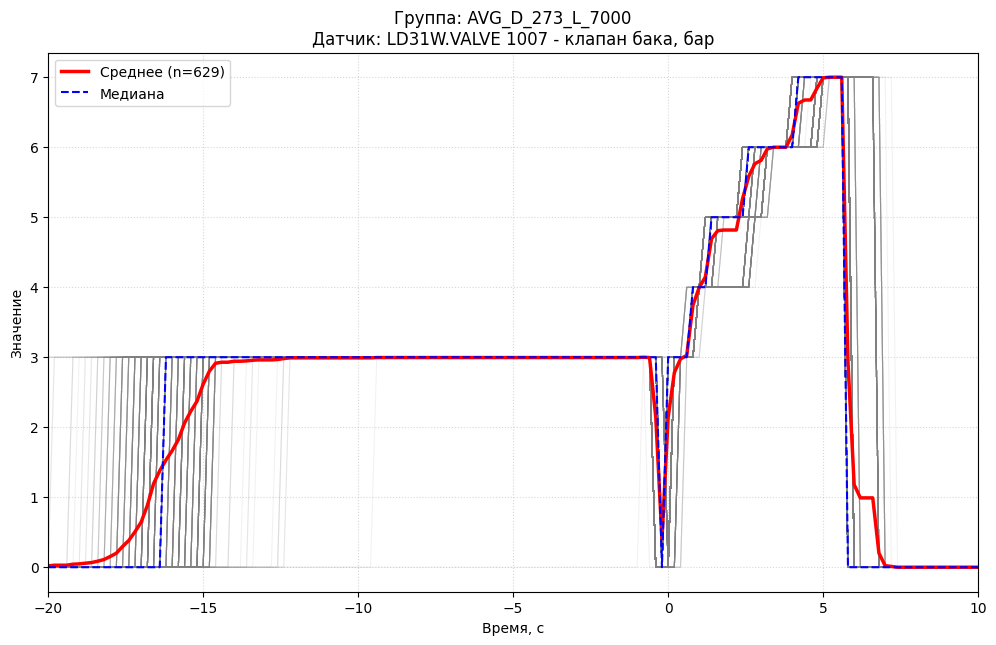

In [23]:
sensor = "LD31W.VALVE 1007 - клапан бака, бар"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg.GRAF_RESALTS_DIR)
plt.xlim(-20, 10)

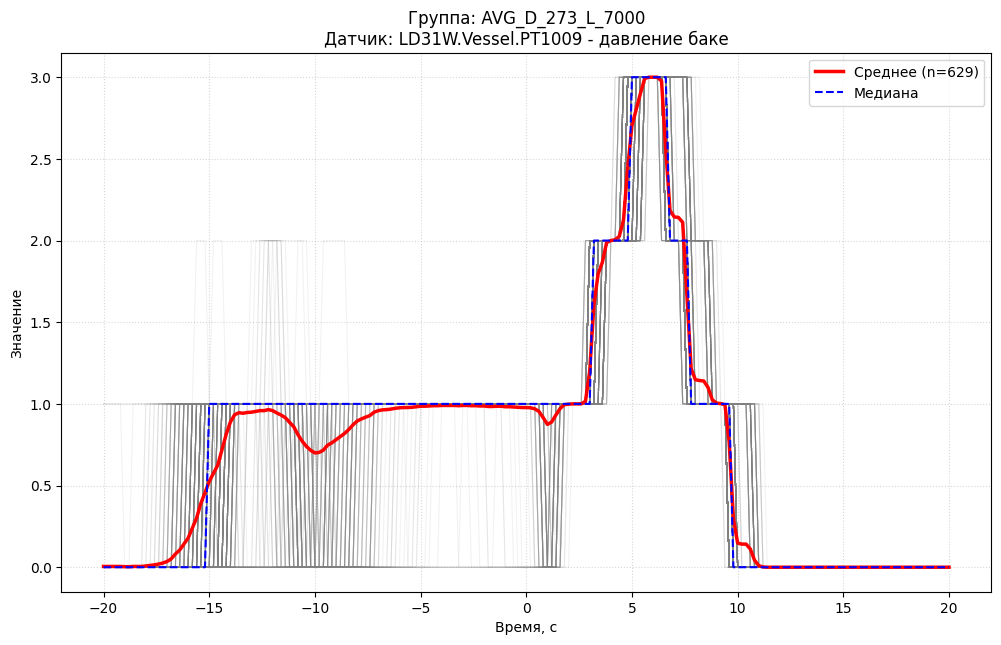

In [24]:
sensor = "LD31W.Vessel.PT1009 - давление баке"

pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg.GRAF_RESALTS_DIR)

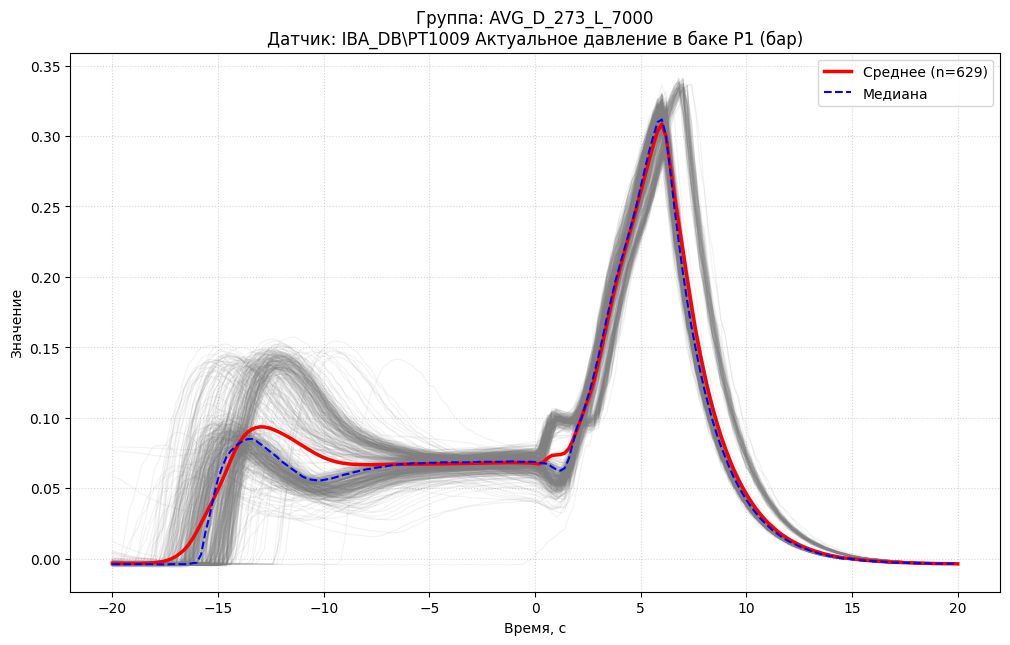

In [25]:
sensor = "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg.GRAF_RESALTS_DIR)

(-20.0, 10.0)

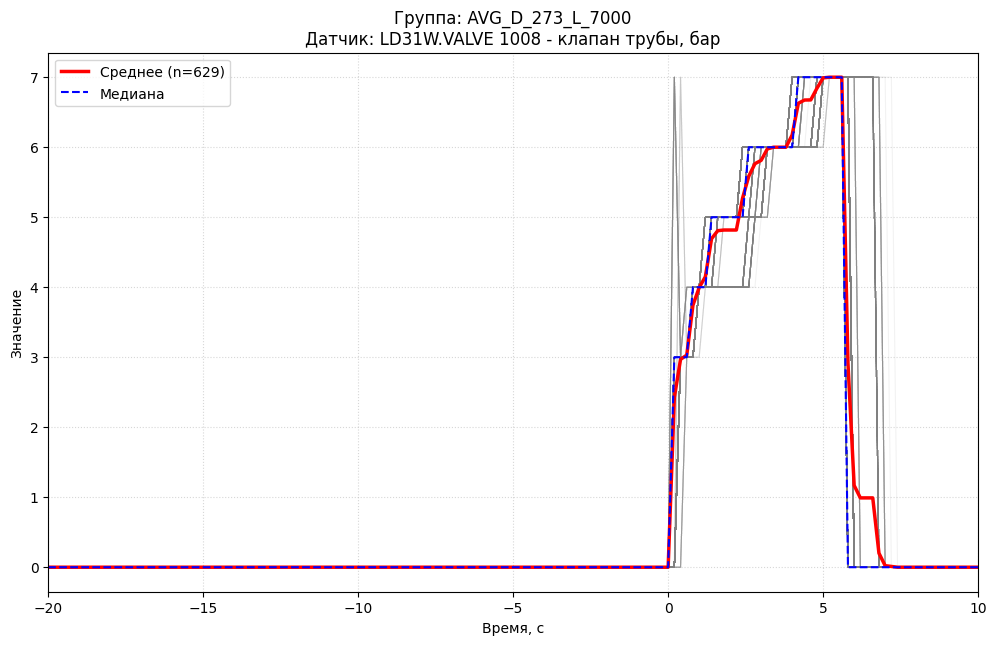

In [26]:
sensor = "LD31W.VALVE 1008 - клапан трубы, бар"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg.GRAF_RESALTS_DIR)
plt.xlim(-20, 10)

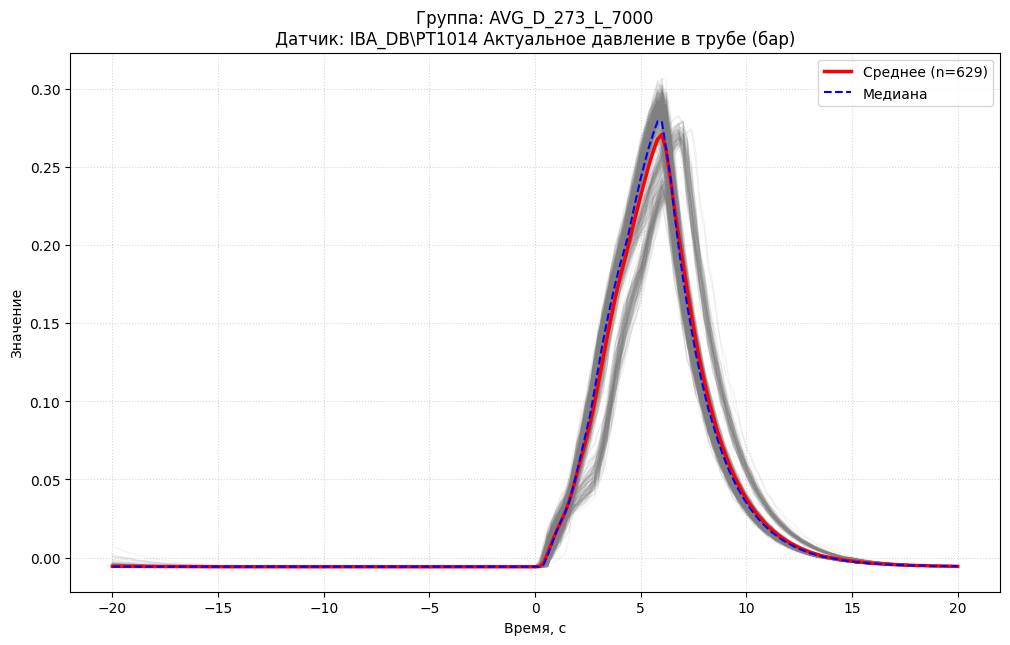

In [27]:
sensor = "IBA_DB\PT1014 Актуальное давление в трубе (бар)"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg.GRAF_RESALTS_DIR)

(-5.0, 10.0)

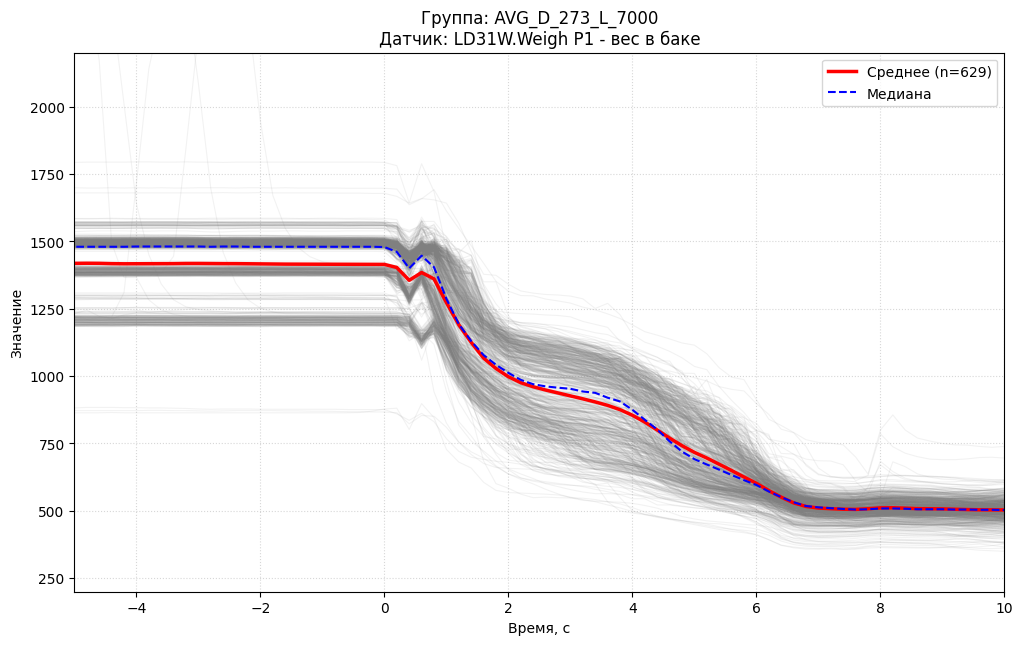

In [28]:
sensor = "LD31W.Weigh P1 - вес в баке"

pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg.GRAF_RESALTS_DIR)
plt.ylim(200, 2200)
plt.xlim(-5, 10)
